<a href="https://colab.research.google.com/github/leelaranivandranki-sketch/Text-topic-extractor-/blob/main/Text_topic_extractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [ ]:
documents = [
    "cat dog animal",
    "dog cat pet",
    "car bus vehicle",
    "bus car transport"
]

print("Documents:")
for i, doc in enumerate(documents, 1):
    print(i, ":", doc)

Documents:
1 : cat dog animal
2 : dog cat pet
3 : car bus vehicle
4 : bus car transport


In [ ]:
words = sorted(set(
    word
    for doc in documents
    for word in re.findall(r'\b[a-zA-Z]+\b', doc.lower())
))

A = np.zeros((len(documents), len(words)))

for i, doc in enumerate(documents):
    doc_words = re.findall(r'\b[a-zA-Z]+\b', doc.lower())

    for j, word in enumerate(words):
        A[i, j] = doc_words.count(word)

print("Words:")
print(words)

print("\nDocument × Word Matrix:")
print(A)

Words:
['animal', 'bus', 'car', 'cat', 'dog', 'pet', 'transport', 'vehicle']

Document × Word Matrix:
[[1. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 1.]
 [0. 1. 1. 0. 0. 0. 1. 0.]]


In [ ]:
U, S, VT = np.linalg.svd(A, full_matrices=False)

print("Singular values:")
print(np.round(S, 3))

print("\nSVD equation:")
print("A = U × Σ × Vᵀ")

# Use the first two hidden directions
number_of_topics = min(2, len(S))

topic_words = VT[:number_of_topics]

for topic in range(number_of_topics):
    print(f"\nTopic {topic + 1}:")

    strengths = topic_words[topic]

    # Show strongest words
    order = np.argsort(np.abs(strengths))[::-1]

    for index in order[:5]:
        print(words[index], "=", round(strengths[index], 3))

Singular values:
[2.236 2.236 1.    1.   ]

SVD equation:
A = U × Σ × Vᵀ

Topic 1:
bus = -0.632
car = -0.632
vehicle = -0.316
transport = -0.316
cat = 0.0

Topic 2:
dog = -0.632
cat = -0.632
animal = -0.316
pet = -0.316
vehicle = 0.0


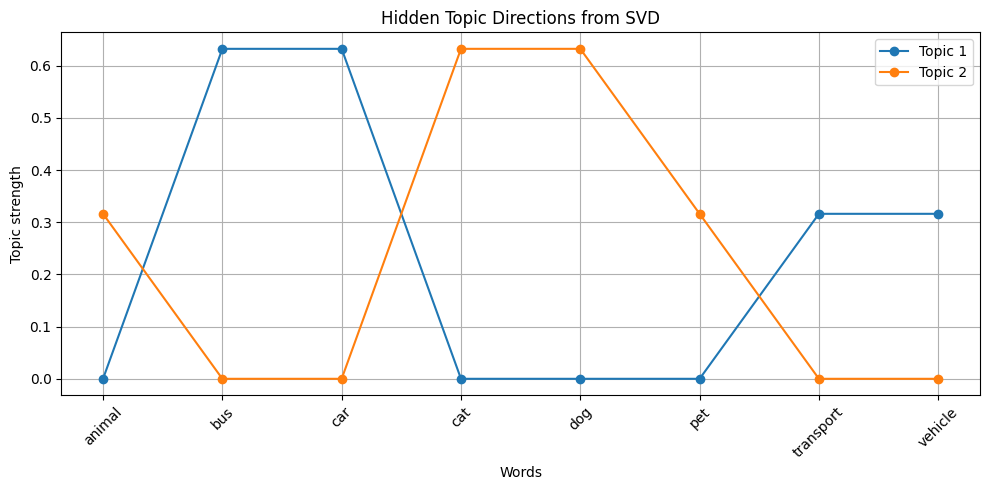

In [ ]:
plt.figure(figsize=(10, 5))

for topic in range(number_of_topics):
    plt.plot(
        words,
        np.abs(VT[topic]),
        marker="o",
        label=f"Topic {topic + 1}"
    )

plt.xlabel("Words")
plt.ylabel("Topic strength")
plt.title("Hidden Topic Directions from SVD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()